In [11]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
df_iris = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target
display(df_iris.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [12]:
df_iris.shape

(150, 5)

In [13]:
df_iris.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
target,0


In [16]:
from sklearn.model_selection import train_test_split

In [47]:
X = df_iris.drop('target', axis=1)
y = df_iris['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=20)


In [48]:
X_train.shape

(105, 4)

In [49]:
X_test.shape

(45, 4)

In [50]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [51]:
X_train_scaled.shape

(105, 4)

In [52]:
 X_test_scaled.shape

(45, 4)

# finiding K value using heustric approach

In [70]:
from sklearn.neighbors import KNeighborsClassifier

In [71]:
import numpy as np

# Use a heuristic for n_neighbors: square root of the number of training samples
n_neighbors_heuristic = int(np.sqrt(X_train_scaled.shape[0]))
knn_model = KNeighborsClassifier(n_neighbors=n_neighbors_heuristic)

In [72]:
knn_model.fit(X_train_scaled, y_train)
y_pred = knn_model.predict(X_test_scaled)

In [73]:
from sklearn.metrics import accuracy_score

In [74]:
# Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)

In [75]:
accuracy

0.9111111111111111

# finiding K value by experimental approach

In [76]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cross_validation_scores = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for i in range(1,16): # ranges of k
    knn = KNeighborsClassifier(n_neighbors=i)

    cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=kf)
    cross_validation_scores.append(cv_scores.mean())



In [77]:
cross_validation_scores

[np.float64(0.9714285714285715),
 np.float64(0.9428571428571428),
 np.float64(0.9619047619047618),
 np.float64(0.980952380952381),
 np.float64(0.9714285714285713),
 np.float64(0.9714285714285713),
 np.float64(0.9428571428571428),
 np.float64(0.9428571428571428),
 np.float64(0.9523809523809523),
 np.float64(0.9523809523809523),
 np.float64(0.9619047619047618),
 np.float64(0.9523809523809523),
 np.float64(0.9428571428571428),
 np.float64(0.9428571428571428),
 np.float64(0.9428571428571428)]

In [78]:
import matplotlib.pyplot as plt


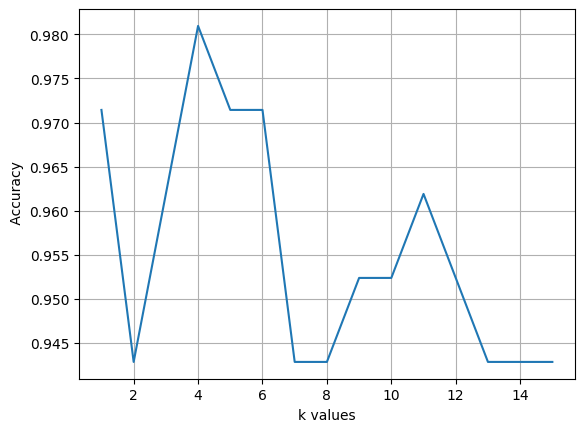

In [82]:
plt.plot(range(1,16),cross_validation_scores)
plt.xlabel('k values')
plt.ylabel(' Accuracy')

plt.grid(True)
plt.show()

# Decision Boundary

In [88]:

from matplotlib.colors import ListedColormap
from sklearn import neighbors, datasets
from sklearn.preprocessing import StandardScaler
from ipywidgets import interact, fixed

def load_data():
    cancer = datasets.load_breast_cancer()
    return cancer

def plot_decision_boundaries(n_neighbors, data, labels):
    h = .02
    cmap_light = ListedColormap(['orange', 'blue'])
    cmap_bold = ListedColormap(['darkorange', 'darkblue'])

    clf = neighbors.KNeighborsClassifier(n_neighbors)
    clf.fit(data, labels)

    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    plt.scatter(data[:, 0], data[:, 1], c=labels, cmap=cmap_bold, edgecolor='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(f'2-Class classification (k = {n_neighbors})')
    plt.show()

cancer = load_data()

# Use only the first two features and standardize them.
X = StandardScaler().fit_transform(cancer.data[:, :2])
y = cancer.target

# Interactive widget
interact(plot_decision_boundaries, n_neighbors=(1, 20), data=fixed(X), labels=fixed(y));

interactive(children=(IntSlider(value=10, description='n_neighbors', max=20, min=1), Output()), _dom_classes=(…

# Test cases

In [93]:
def predict_new_data():
  sepal_length = float(input("Enter sepal length: "))
  sepal_width = float(input("Enter sepal width: "))
  petal_length = float(input("Enter petal length: "))
  petal_width = float(input("Enter petal width: "))

  X_new = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
  X_new_scaled = scaler.transform(X_new)
  prediction = knn_model.predict(X_new_scaled)
  if prediction[0] == 0:
    print("The flower is a Setosa.")
  elif prediction[0] == 1:
    print("The flower is a Versicolor.")
  else:
    print("The flower is a Virginica.")


In [94]:
predict_new_data()

Enter sepal length: 2
Enter sepal width: 2.4
Enter petal length: 3
Enter petal width: 4.5
The flower is a Versicolor.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [95]:
# using data from the dataset
#sepal length=5.1
#sepal width=3.5
#petal length=1.4
#petal width=0.2 and output should be  Setosa


In [96]:
predict_new_data()

Enter sepal length: 5.1
Enter sepal width: 3.5
Enter petal length: 1.4
Enter petal width: 0.2
The flower is a Setosa.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# The KNN classifier, particularly when tuned with cross-validation to find an optimal k value, proves to be a highly effective method for classifying Iris species based on their sepal and petal measurements, achieving excellent accuracy.